In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import os
print("Current folder:", os.getcwd())
print(os.listdir())

Current folder: c:\Users\User\Projects\climate-challenge-week0\notebooks
['compare_countries.ipynb', 'ethiopia_eda.ipynb', 'kenya_eda.ipynb', 'nigeria_eda.ipynb', 'sudan_eda.ipynb', 'tanzania_eda.ipynb']


In [7]:
ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")

In [9]:
import pandas as pd

ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")

ethiopia["country"] = "Ethiopia"
sudan["country"] = "Sudan"
kenya["country"] = "Kenya"
nigeria["country"] = "Nigeria"
tanzania["country"] = "Tanzania"

df = pd.concat([ethiopia, sudan, kenya, nigeria, tanzania])

In [ ]:
import os
print("Current folder:", os.getcwd())
print("Files here:", os.listdir())

Current folder: c:\Users\User\Projects\climate-challenge-week0\notebooks
Files here: ['compare_countries.ipynb', 'ethiopia_eda.ipynb', 'kenya_eda.ipynb', 'nigeria_eda.ipynb', 'sudan_eda.ipynb', 'tanzania_eda.ipynb']


In [12]:
df["Date"] = pd.to_datetime(df["Date"])
df["year"] = df["YEAR"]
df["month"] = df["Month"]

In [14]:
df["Date"] = pd.to_datetime(df["Date"])
df["month_period"] = df["Date"].dt.to_period("M")

In [ ]:
df["year_month"] = df["Date"].dt.strftime("%Y-%m")

In [ ]:
monthly_temp = df.groupby(["country", "year_month"])["T2M"].mean().reset_index()

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])
df["month_period"] = df["Date"].dt.to_period("M")

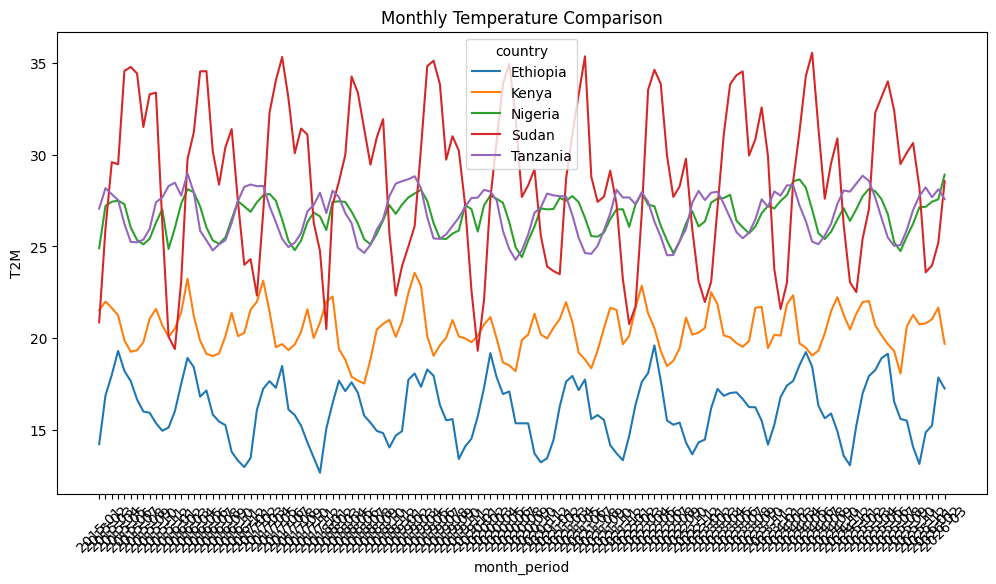

In [ ]:
monthly_temp = df.groupby(["country", "month_period"])["T2M"].mean().reset_index()

monthly_temp["month_period"] = monthly_temp["month_period"].astype(str)

plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_temp, x="month_period", y="T2M", hue="country")
plt.xticks(rotation=45)
plt.title("Monthly Temperature Comparison")
plt.show()

In [ ]:
monthly_temp = df.groupby(["country", "month_period"])["T2M"].mean().reset_index()

monthly_temp = monthly_temp.sort_values("month_period")

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])
df["month_period"] = df["Date"].dt.to_period("M")

In [ ]:
precip_summary = df.groupby("country")["PRECTOTCORR"].agg(["mean", "median", "std"])
print(precip_summary)

              mean  median       std
country                             
Ethiopia  3.633795    0.82  6.289061
Kenya     1.468162    0.38  3.180228
Nigeria   4.213914    1.84  7.266742
Sudan     0.643875    0.00  3.057672
Tanzania  3.740256    0.64  8.003947


In [ ]:
heat = df[df["T2M_MAX"] > 35]
heat_counts = heat.groupby(["country", "YEAR"]).size().reset_index(name="days")

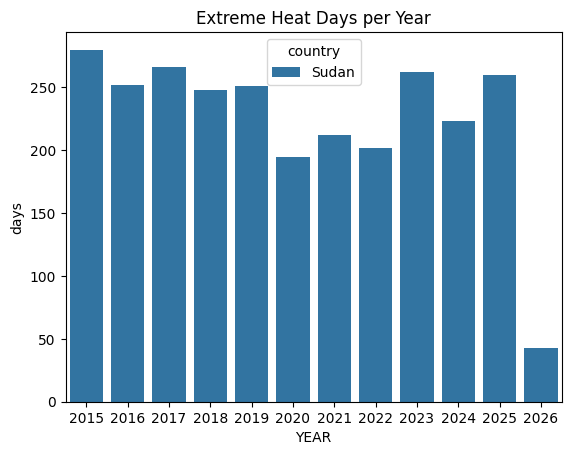

In [ ]:
sns.barplot(data=heat_counts, x="YEAR", y="days", hue="country")
plt.title("Extreme Heat Days per Year")
plt.show()

In [ ]:
dry = df[df["PRECTOTCORR"] < 1]
dry_counts = dry.groupby(["country", "YEAR"]).size().reset_index(name="days")

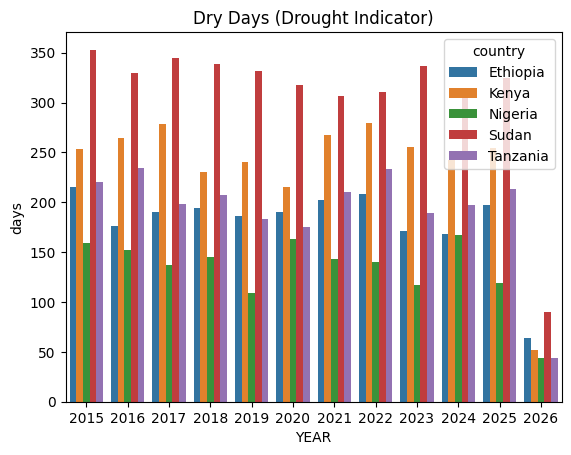

In [ ]:
sns.barplot(data=dry_counts, x="YEAR", y="days", hue="country")
plt.title("Dry Days (Drought Indicator)")
plt.show()

In [ ]:
from scipy.stats import f_oneway

groups = [df[df["country"] == c]["T2M"] for c in df["country"].unique()]
stat, p = f_oneway(*groups)

print("ANOVA p-value:", p)

ANOVA p-value: 0.0


In [ ]:
ranking = df.groupby("country").agg({
    "T2M": "mean",
    "PRECTOTCORR": "std"
}).rename(columns={"T2M": "temp_mean", "PRECTOTCORR": "rain_variability"})

ranking = ranking.sort_values(by=["temp_mean", "rain_variability"], ascending=False)

print(ranking)

          temp_mean  rain_variability
country                              
Sudan     28.759007          3.057672
Tanzania  26.802422          8.003947
Nigeria   26.656928          7.266742
Kenya     20.427600          3.180228
Ethiopia  16.068500          6.289061
